<a href="https://colab.research.google.com/github/marcos-henestrosa/PAS_Procesos_estoc-sticos/blob/main/GP_Marcos_Henestrosa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

***SIMULACIÓN DE PROCESOS GAUSSIANOS***

El objetivo es aprender a simular trayectorias de un GP, usando algunas de las herramientas más habituales de _machine learning_ (las que hemos visto: Python, Numpy, matplotlib). Como resultado final, generaremos las imágenes vistas en las diapositivas.



## 1. Muestras de una normal multivariante / multidimensional

Puesto que simular trayectorias de un GP involucra simular de una normal multivariante, veamos primero cómo hacer esto.

En la siguiente celda se deben obtener 50 muestras de una normal 3-dimensional $(X_1,X_2,X_3)$ que sigue una distribución normal $\mathcal{N}(0,I_{3\times 3})$

Para ello, utiliza la función `np.random.multivariate_normal` (busca en internet cómo usarla).

Además, visualiza el resultado obtenido, así como su shape.

In [ ]:
import numpy as np
vector_medias = np.zeros(3)
matriz_covarianzas = np.eye(3)
samples = np.random.multivariate_normal(vector_medias,matriz_covarianzas,size=50)

print("Shape:", samples.shape)
print("Muestras: ")
print(samples)

Shape:  (50, 3)
Muestras: 
[[-0.33052548 -0.1182019  -0.16014501]
 [ 1.28189862  0.24375831  0.22571013]
 [-0.13325285  1.59465284  1.38491546]
 [-2.12376928  1.43877666 -0.62114694]
 [-1.5529324  -1.70887916 -1.8671075 ]
 [-0.81647257  0.62127088 -0.10776753]
 [ 0.92075296 -0.80317602 -0.53146856]
 [-1.20712622  1.12370237 -0.48941693]
 [-0.20917842  0.15023855  0.60257775]
 [-0.16883758 -1.74203668  1.24771003]
 [ 1.02492009  0.14387947  1.52531535]
 [-2.1603845   0.06546429  0.13475016]
 [-0.92550959 -0.08960176  0.12906913]
 [ 0.43254669 -0.44888888 -0.73654168]
 [ 0.97187474  1.28317818 -0.14654093]
 [-0.35605483 -0.52392282 -1.08848862]
 [ 0.64628286 -0.1949405   1.87908348]
 [-0.69907674  0.27783186  0.21306936]
 [ 0.04590464 -0.5980054   0.05266771]
 [-0.80707786 -0.20251455 -2.42640308]
 [ 0.14538248 -0.7805027   0.17871971]
 [ 1.48482957 -0.00805644 -0.02416365]
 [-1.34879352 -0.32044223  1.72634624]
 [-0.32425364  0.8690328   0.31939387]
 [-0.46917615 -1.75760244  0.91885046

Haz ahora lo mismo pero para una normal con matriz de covarianzas que no sea la identidad, sino por ejemplo $$\Sigma=\begin{pmatrix}1 & 0 & 0 \\
0 & 10 & 0 \\
0 & 0 & 100 \end{pmatrix}$$

Puedes simplificar algo el código si usas la función `np.diag`.

¿Qué diferencias esperarías ver en las muestras obtenidas?


In [ ]:
import numpy as np

vector_medias = np.zeros(3)
matriz_covarianzas = np.diag([1,10,100])
samples = np.random.multivariate_normal(vector_medias, matriz_covarianzas,size=50)

np.set_printoptions(suppress=True, precision=5) # Para que no aparezca en notación científica.
print("Shape:", samples.shape)
print("Muestras: ")
print(samples)

Shape: (50, 3)
Muestras: 
[[  0.41795  -1.99471  -7.52838]
 [  1.4968    4.99494 -11.70177]
 [ -0.23355  -3.31206  -0.10954]
 [ -0.7756    4.69206  15.5805 ]
 [  0.81915  -3.95968  18.14995]
 [ -0.83517  -1.72772   2.26058]
 [ -0.75354  -1.15426 -13.20232]
 [ -1.02991   4.21694   5.33827]
 [ -0.18275  -3.64878  -1.47184]
 [ -1.09588   2.10093   5.24154]
 [  0.19176  -2.65028   6.15989]
 [ -1.09867  -0.04474  -5.54552]
 [ -1.47382   2.99979  15.68071]
 [ -0.67076  -0.15994   8.61644]
 [  1.31585   4.05731  10.6152 ]
 [ -0.2158   -5.7541    3.75722]
 [ -0.86316  -0.20016   9.8462 ]
 [ -1.76065  -0.77113  -5.94348]
 [ -1.29862   0.79764  -7.56007]
 [ -0.45153  -1.63321  -5.80691]
 [ -0.53041   5.9675    5.10695]
 [  0.98479   2.99764   2.10083]
 [  1.37835  -2.52634  -9.50407]
 [  0.64932   2.16175   9.34212]
 [ -2.44402  -0.52256 -15.02976]
 [  0.43758  -1.70865 -11.81623]
 [  0.5152   -1.01092   1.22882]
 [  0.55192  -1.7117  -12.22871]
 [ -0.67319   0.03545   3.11354]
 [  1.46954  -0.7

## 2. Simular un GP con kernel RBF

En esta sección vamos a definir una función `simular_GP_RBF` que nos permita simular un GP con kernel RBF. Y a continuación la usamos para generar imágenes similares a las de las diapositivas. Usaremos función de medias constantemente igual a cero.

En el punto 5 se explicará la manera más limpia de usar otras funciones de medias. También se comentará la manera más adecuada para pasar el kernel como argumento de la función. Es decir, de modo que no sea necesario definir `simular_GP_RBF`, sino simplemente `simular_GP` (y que el kernel se pase como argumento de la función). Todo ello necesita del concepto de _clases_, algo que (creo) no se estudia en el grado en matemáticas.

<>:75: SyntaxWarning: invalid escape sequence '\s'
<>:75: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_5755/4030244091.py:75: SyntaxWarning: invalid escape sequence '\s'
  fig.suptitle('Efectos del lengthscale con $\sigma$ = 1') # Esta función es para crear un título global para las tres gráficas


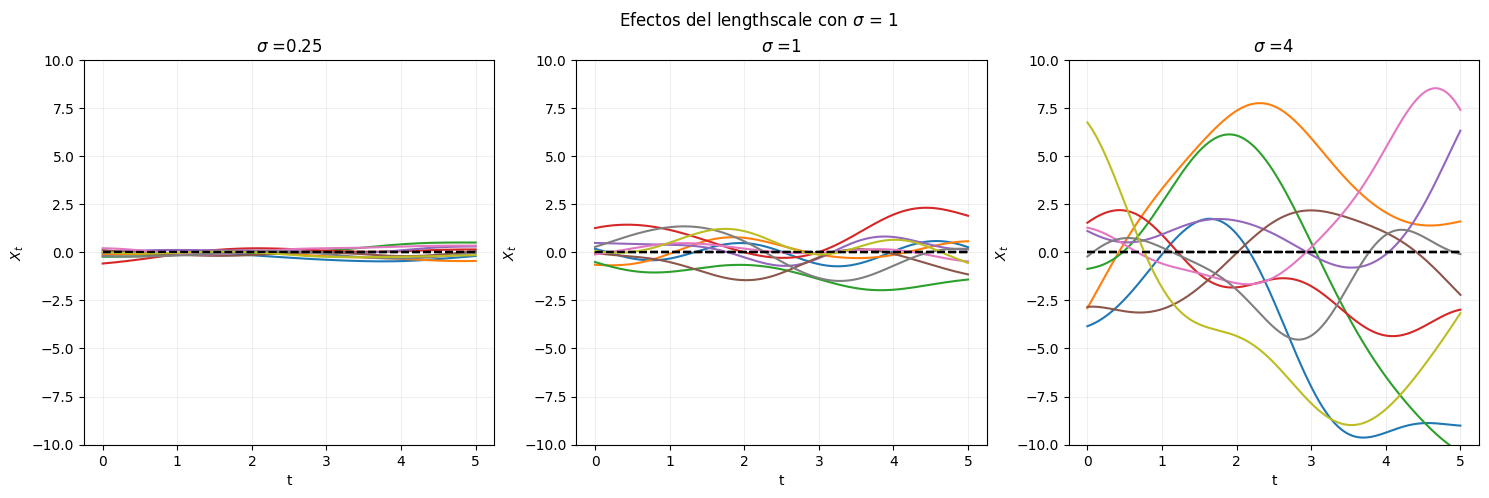

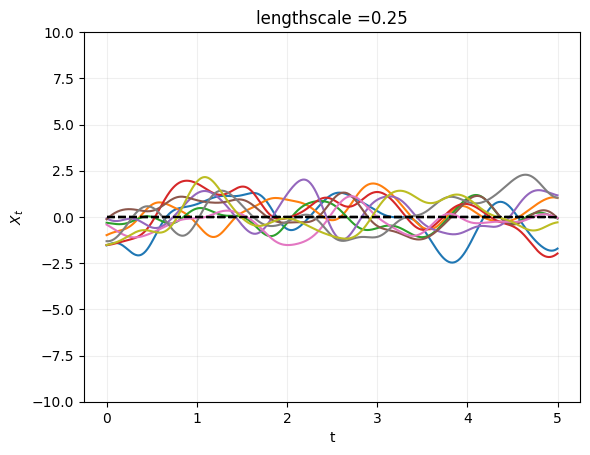

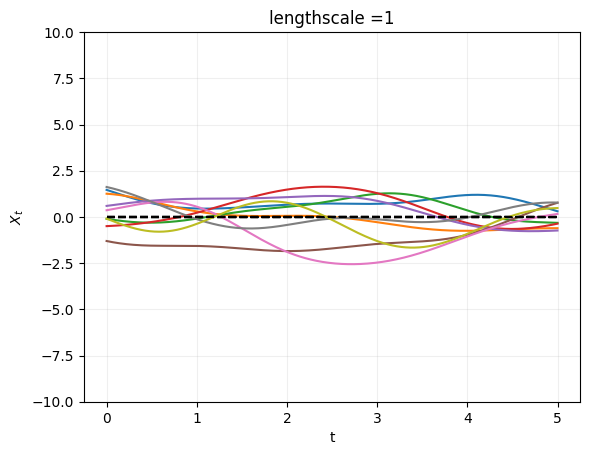

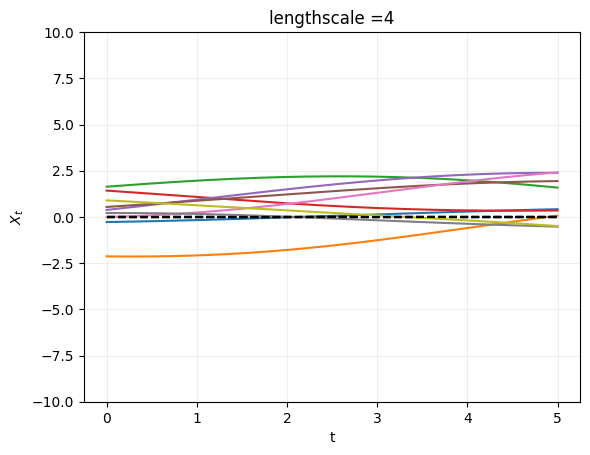

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


"""
# Defino una función donde:
t es el vector de localizaciones donde se quiere simular el GP (el grid).
sigma_sq es la desviación típica (parámetro de este kernel).
l es el lengthscale (parámetro de este kernel).
num_samples es la cantidad de muestras/trayectorias que se quieren obtener.

La salida será una matriz samples (de dimensión (num_samples,t.size)) que contendrá en cada fila los datos de cada trayectoria a representar.
"""

def simular_GP_RBF(t, sigma_sq=1, l=1, num_samples=1):


  # Calculo el vector de medias.
      vector_medias = np.zeros(len(t))

  # Calculo la matriz de covarianzas. Aprovecho el broadcasting de numpy.

      diff= t[:,np.newaxis] - t[np.newaxis,:] # t es un vector; t[:,np.newaxis] y t[np.newaxis,:] son respectivamente matriz columna y matriz fila (también se podría haber usado reshape).
                                              # Como las dimensiones no coinciden, numpy las transforma en matrices (cuadradas de dimensión t.size) repitiendo respectivamente la primera
                                              # columna y la primera fila. Obtenemos la matriz de diferencias donde el elemento (i,j) es t_i-t_j.

      matriz_covs=(sigma_sq**2)*np.exp(-(diff**2)/(2*(l**2))) # Obtenemos la matriz de covarianzas. Dentro de la exponencial aparece la matriz de diferencias y numpy automáticamente
                                                              # realiza la operación elemento a elemento.

  # Obtengo las muestras y las devuelvo.
      samples = np.random.multivariate_normal(vector_medias, matriz_covs,num_samples)

      return samples



#Vamos a obtener a continuación las gráficas que se nos piden:
t=np.linspace(0,5,500)


#Gráficas con el lengthscale fijo (igual a 1) y variando la varianza (diapositiva 59):
fig, ax=plt.subplots(1,3,figsize=(18,5)) # Uso esta función para que las tres gráficas me aparezcan en la posición que yo deseo y no de manera independiente y hacia abajo.

samples=simular_GP_RBF(t,0.25,1,10)
for i in range(1,10):
    ax[0].plot(t,samples[i].reshape(t.size,),t,np.zeros(t.size,),'--k')
    ax[0].grid(alpha=0.2)
    ax[0].set_ylim([-10,10])
ax[0].set_title(r'$\sigma$ =0.25')
ax[0].set_ylabel('$X_t$')
ax[0].set_xlabel('t')



samples=simular_GP_RBF(t,1,1,10)
for i in range(1,10):
    ax[1].plot(t,samples[i].reshape(t.size,),t,np.zeros(t.size,),'--k')
    ax[1].grid(alpha=0.2)
    ax[1].set_ylim([-10,10])
ax[1].set_title(r'$\sigma$ =1')
ax[1].set_ylabel('$X_t$')
ax[1].set_xlabel('t')


samples=simular_GP_RBF(t,4,1,10)
for i in range(1,10):
  ax[2].plot(t,samples[i].reshape(t.size,),t,np.zeros(t.size,),'--k')
  ax[2].grid(alpha=0.2)
  ax[2].set_ylim([-10,10])
ax[2].set_title(r'$\sigma$ =4')
ax[2].set_ylabel('$X_t$')
ax[2].set_xlabel('t')


fig.suptitle('Efectos del lengthscale con $\sigma$ = 1') # Esta función es para crear un título global para las tres gráficas
plt.show()



#Gráficas con la varianza fija (igual a 1) y variando el lengthscale (diapositiva 62). Para ver la diferencia, en este caso dibujaré las tres gráficas por separado en vez de ponerlas en línea,
# a diferencia del caso anterior.
samples=simular_GP_RBF(t,1,0.25,10)
for i in range(1,10):
    plt.plot(t,samples[i].reshape(t.size,),t,np.zeros(t.size,),'--k')
    plt.grid(alpha=0.2)
    plt.ylim([-10,10])
plt.title('lengthscale =0.25')
plt.ylabel('$X_t$')
plt.xlabel('t')
plt.show()


samples=simular_GP_RBF(t,1,1,10)
for i in range(1,10):
  plt.plot(t,samples[i].reshape(t.size,),t,np.zeros(t.size,),'--k')
  plt.grid(alpha=0.2)
  plt.ylim([-10,10])
plt.title('lengthscale =1')
plt.ylabel('$X_t$')
plt.xlabel('t')
plt.show()

samples=simular_GP_RBF(t,1,4,10)
for i in range(1,10):
  plt.plot(t,samples[i].reshape(t.size,),t,np.zeros(t.size,),'--k')
  plt.grid(alpha=0.2)
  plt.ylim([-10,10])
plt.title('lengthscale =4')
plt.ylabel('$X_t$')
plt.xlabel('t')
plt.show()


## 3. Simular un GP con kernel periódico

En esta sección vamos a definir una función `simular_GP_periodic` que nos permita simular de un GP con kernel periódico. Y a continuación la usamos para generar imágenes similares a las de las diapositivas. Usaremos función de medias constantemente igual a cero.

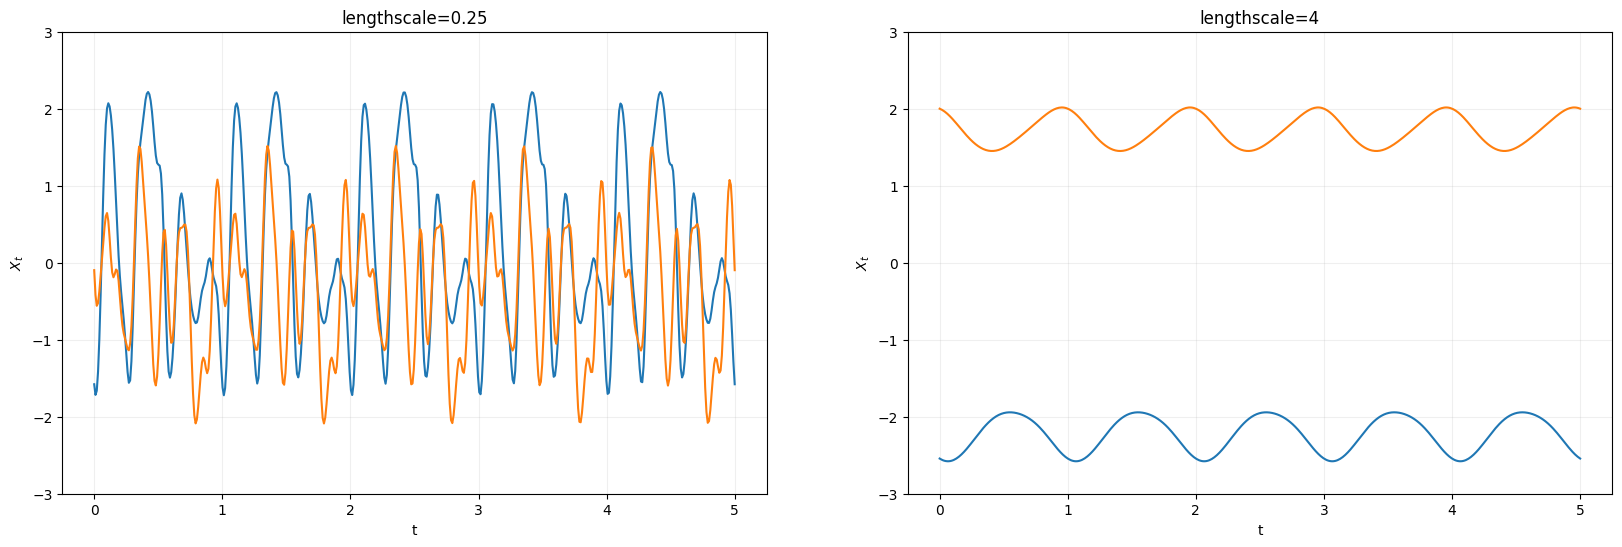

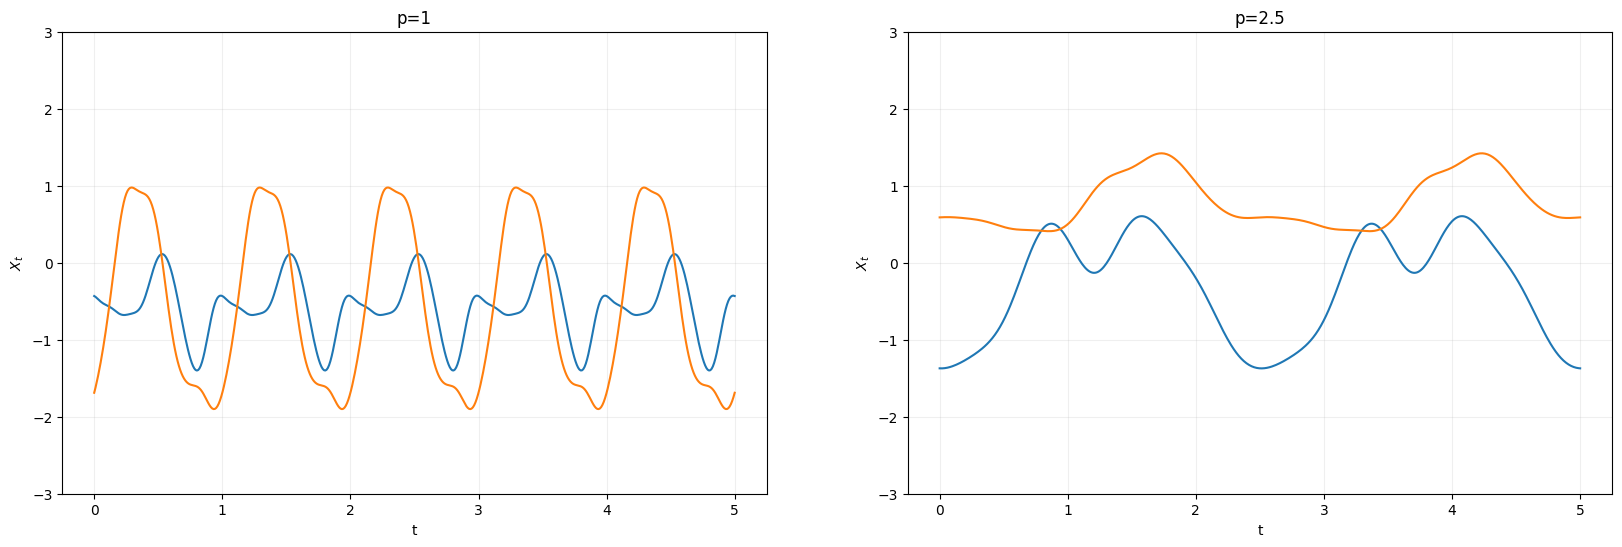

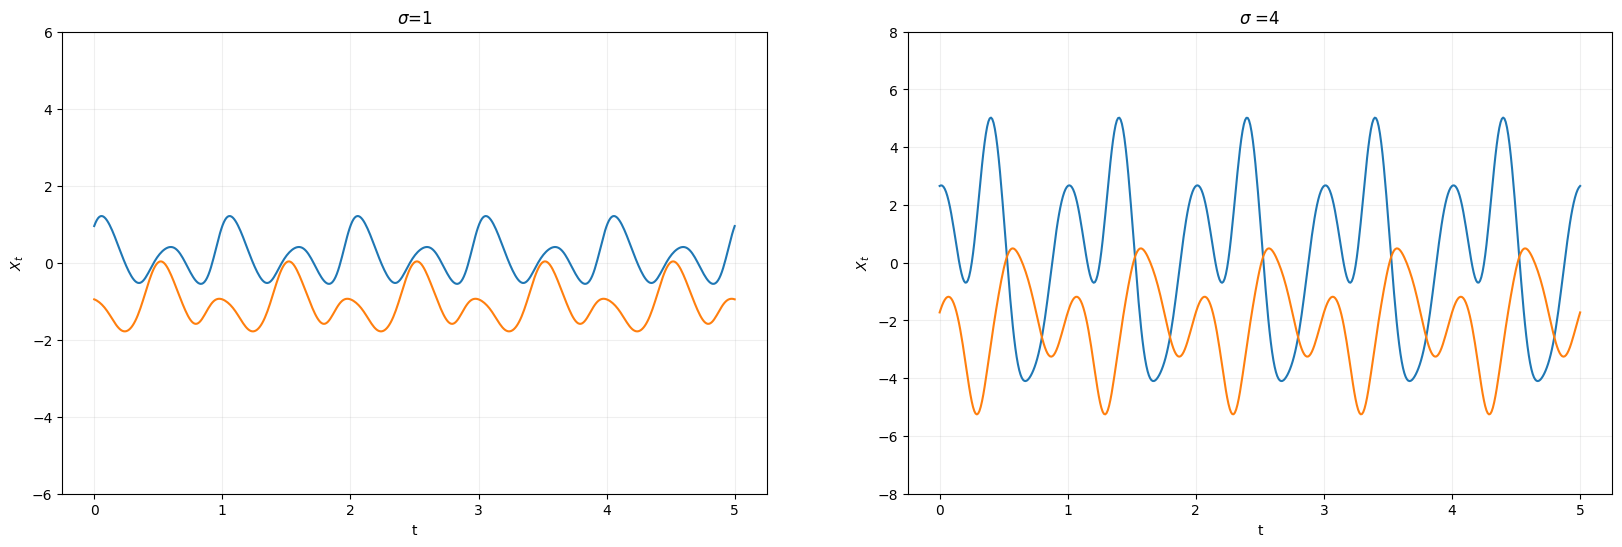

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math


"""
Análogo al caso anterior. Simplemente en la entrada de la función añadimos el parámetro p
"""

def simular_GP_periodic(t,sigma_sq=1,l=1,p=1,num_samples=1):
      vector_medias = np.zeros(len(t))


  #Calculo una matriz de diferencias y la matriz de covarianzas.
      diff= t[:,np.newaxis] - t[np.newaxis,:]
      matriz_covs=(sigma_sq**2)*np.exp((-2/(l**2))*(np.sin((np.abs(diff)*np.pi)/(p)))**2)



  # Obtengo las muestras/simulaciones del GP y las devuelvo.
      samples = np.random.multivariate_normal(vector_medias, matriz_covs,num_samples)

      return samples



# Dibujamos las gráficas que se nos piden:
t=np.linspace(0,5,500)


# Gráficas diapositiva 72 (varianza=1, p=1 y l=0.25, l=4):
fig, ax=plt.subplots(1,2,figsize=(20,6))

samples=simular_GP_periodic(t,1,0.25,1,2)
for i in range(1,3):
      ax[0].plot(t,samples[i-1].reshape(t.size,))
      ax[0].grid(alpha=0.2)
      ax[0].set_ylim([-3,3])
ax[0].set_xlabel('t')
ax[0].set_ylabel('$X_t$')
ax[0].set_title('lengthscale=0.25')

samples=simular_GP_periodic(t,1,4,1,2)
for i in range(1,3):
      ax[1].plot(t,samples[i-1].reshape(t.size,))
      ax[1].grid(alpha=0.2)
      ax[1].set_ylim([-3,3])
ax[1].set_xlabel('t')
ax[1].set_ylabel('$X_t$')
ax[1].set_title('lengthscale=4')

plt.show()



#Gráficas diapositiva 74 (varianza=1, l=1 y p=1, p=2.5):
fig, ax=plt.subplots(1,2,figsize=(20,6))

samples=simular_GP_periodic(t,1,1,1,2)
for i in range(1,3):
      ax[0].plot(t,samples[i-1].reshape(t.size,))
      ax[0].grid(alpha=0.2)
      ax[0].set_ylim([-3,3])
ax[0].set_xlabel('t')
ax[0].set_ylabel('$X_t$')
ax[0].set_title('p=1')

samples=simular_GP_periodic(t,1,1,2.5,2)
for i in range(1,3):
      ax[1].plot(t,samples[i-1].reshape(t.size,))
      ax[1].grid(alpha=0.2)
      ax[1].set_ylim([-3,3])
ax[1].set_xlabel('t')
ax[1].set_ylabel('$X_t$')
ax[1].set_title('p=2.5')

plt.show()



# Gráficas diapositiva 76 (l=1, p=1 y desviación típica=1, desviación típica=4):
fig, ax=plt.subplots(1,2,figsize=(20,6))

samples=simular_GP_periodic(t,1,1,1,2)
for i in range(1,3):
      ax[0].plot(t,samples[i-1].reshape(t.size,))
      ax[0].grid(alpha=0.2)
      ax[0].set_ylim([-6,6])
ax[0].set_xlabel('t')
ax[0].set_ylabel('$X_t$')
ax[0].set_title(r'$\sigma$=1')

samples=simular_GP_periodic(t,4,1,1,2)
for i in range(1,3):
      ax[1].plot(t,samples[i-1].reshape(t.size,))
      ax[1].grid(alpha=0.2)
      ax[1].set_ylim([-8,8])
ax[1].set_xlabel('t')
ax[1].set_ylabel('$X_t$')
ax[1].set_title(r'$\sigma$ =4')


plt.show()



## 4. Simular un GP con kernel DPK (concretamente, polinómico hasta grado $m$)

En esta sección vamos a definir una función `simular_GP_DPKpoly` que nos permita simular de un GP con kernel DPK. Concretamente, un kernel DPK con funciones base $1$, $t$, $\dots$, $t^m$. Y a continuación la usamos para generar imágenes similares a las de las diapositivas. Usaremos función de medias constantemente igual a cero.

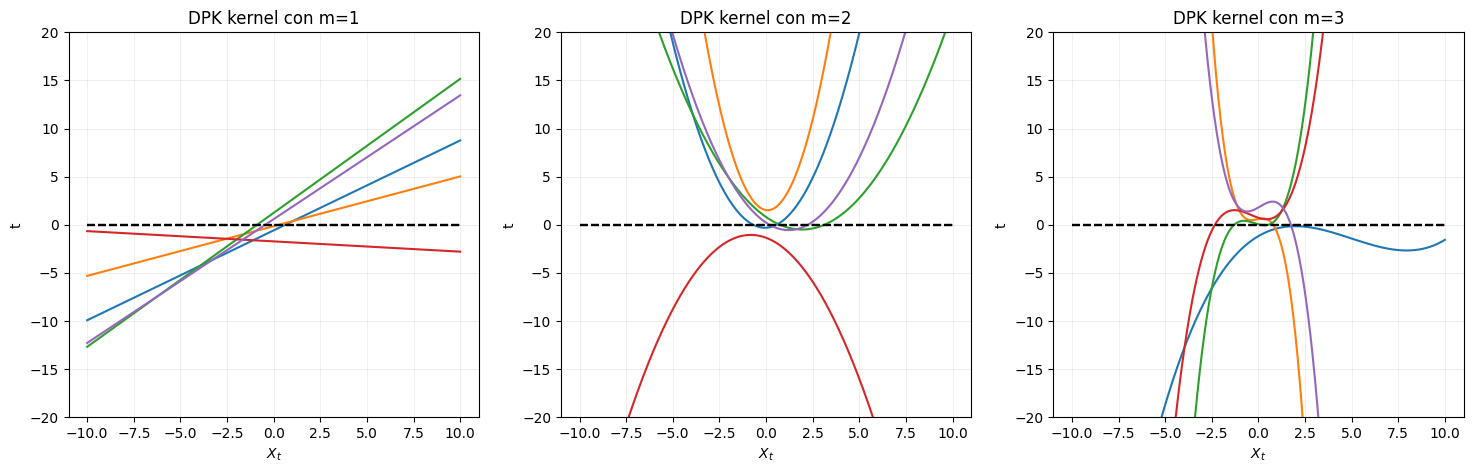

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math

"""
En este caso, el kernel DPK polinómico solo posee un parámetro m.
"""

def simular_GP_DPKpoly(t,m,num_samples=1):

      vector_medias=np.zeros(len(t))

      # Sabemos que este kernel se define como k(t,p)= 1*1 + t*p + t^2*p^2 + ... + t^m*p^2. Se puede comprobar mentalmente que la matriz de covarianzas entonces se puede factorizar
      # como F * Traspuesta de F, donde llamando n al número de elementos del vector t, la primera matriz es de dimensión (n,m+1) y la segunda (m+1,n). En la primera matriz F, cada fila contiene
      # las potencias de cada elemento del vector t (por ejemplo si t=[t1,...tn] entonces la primera fila contiene los elementos 1, t1, t1^2,..., t1^m; y la última fila 1, tn, tn^2,..., tn^m)
      # La segunda matriz igual pero por columnas en vez de por filas (es la traspuesta). Apliquemos esto aquí:

      matriz_1=np.vander(t)            # La matriz vander de numpy te pone las potencias "hacia la izquierda", pero las necesitamos a la derecha.
      matriz_1=matriz_1[:,::-1]        # Por eso intercambiamos el orden de las columnas (esta es nuestra F).
      matriz_2=np.transpose(matriz_1)  # Obtenemos F traspuesta.
      submatriz_1=matriz_1[:,0:m+1]    # Solo necesitamos hasta la potencia m-ésima, por eso consideramos solo las primeras m+1 columnas de F (dimensión ahora (n,m+1)).
      submatriz_2=matriz_2[0:m+1,:]    # Solo necesitamos hasta la potencia m-ésima, por eso consideramos solo las primeras m+1 filas de F traspuesta (dimensión ahora (m+1,n)).

      matriz_covs=submatriz_1@submatriz_2   # Las multiplicamos para obtener la matriz de covarianzas.
      matriz_covs= matriz_covs+ np.eye(len(t))* 1e-9   # Añadimos un "jitter" para que sea seguro semidefinida positiva y no de error.
      samples=np.random.multivariate_normal(vector_medias, matriz_covs,num_samples)   #Obtenemos las muestras y las devolvemos.

      return samples


# Obtenemos las gráficas que se nos piden (diapositiva 89):
t=np.linspace(-10,10,500)
fig, ax=plt.subplots(1,3,figsize=(18,5))

# Caso m=1:
samples=simular_GP_DPKpoly(t,1,5)
for i in range(1,6):
      ax[0].plot(t,samples[i-1].reshape(t.size,),t,np.zeros(t.size),'--k')
      ax[0].grid(alpha=0.2)
      ax[0].set_ylim([-20,20])
ax[0].set_title('DPK kernel con m=1')
ax[0].set_xlabel('$X_t$')
ax[0].set_ylabel('t')

# Caso m=2:
samples=simular_GP_DPKpoly(t,2,5)
for i in range(1,6):
      ax[1].plot(t,samples[i-1].reshape(t.size,),t,np.zeros(t.size),'--k')
      ax[1].grid(alpha=0.2)
      ax[1].set_ylim([-20,20])
ax[1].set_title('DPK kernel con m=2')
ax[1].set_xlabel('$X_t$')
ax[1].set_ylabel('t')

# Caso m=3:
samples=simular_GP_DPKpoly(t,3,5)
for i in range(1,6):
      ax[2].plot(t,samples[i-1].reshape(t.size,),t,np.zeros(t.size),'--k')
      ax[2].grid(alpha=0.2)
      ax[2].set_ylim([-20,20])
ax[2].set_title('DPK kernel con m=3')
ax[2].set_xlabel('$X_t$')
ax[2].set_ylabel('t')

plt.show()





## 5. Opcional: ¿Cómo hacer que el kernel se pase como parámetro? ¿y la función de medias?

Estas preguntas, bastante generales, se pueden abordar de muchas maneras. En esta sección se presenta muy brevemente una solución basada en el paradigma de programación orientada a objetos (POO). Es la manera más habitual de programar en Python y en muchos otros lenguajes.

La idea de la POO es estructurar el código usando el concepto de _clase_. Una _clase_ es algo ``parecido'' a un _struct_, que probablemente se viese en las asignaturas de C++, aunque una clase tiene mayor funcionalidad. Concretamente, una _clase_ es una estructura que nos permite crear objetos que contienen dos cosas principalmente:
* Atributos: valores que forman parte del objeto.
* Métodos: acciones que puede realizar el objeto.

A continuación definimos una _clase_ para describir el kernel RBF. La clase define dos atributos:
* ```self.sigma_sq```: es el parámetro $\sigma^2$.
* ```self.lengthscale```: es el parámetro $\ell$.
Y la clase define un método (además del ```__init__``` básico, que se usa para crear un objeto de la clase):
* ```__call__(self, t, s)```: permite evaluar el kernel usando como inputs los arrays t y s. Es decir, calcula la matriz $(k(t_i, s_j))_{ij}$.

In [ ]:
class RBF:
  def __init__(self, sigma_sq=1, lengthscale=1):
    self.sigma_sq = sigma_sq
    self.lengthscale = lengthscale
  def __call__(self, t, s):
    dists = t[:, None] - s[None, :]
    cov_matrix = self.sigma_sq * np.exp(-0.5 * (dists / self.lengthscale)**2)
    return cov_matrix

En la celda anterior simplemente hemos definido "qué es un objeto de tipo RBF".

En la celda siguiente, utilizamos la clase recién definida para crear un objeto concreto de ese tipo:

In [ ]:
my_kernel = RBF(sigma_sq=1, lengthscale=1)
print(type(my_kernel))  # Deberíamos ver que este objeto es de tipo "RBF"

t = np.linspace(0,10,100)
cov_mat = my_kernel(t,t)   # Aquí estamos usando el método __call__ (es un método especial que se utiliza de esta manera)
print(cov_mat.shape)  # Aquí deberíamos obtener una matriz con shape (100, 100), puesto que es la matriz de covarianzas de evaluar el GP en t (que tiene tamaño 100)

A continuación definimos una clase para la función de medias constantemente igual a cero:

In [ ]:
class Zero_Mean_Function:
  def __init__(self):
    pass
  def __call__(self, t):
    return np.zeros_like(t)

Y creamos un objeto de ese tipo:

In [ ]:
my_mf = Zero_Mean_Function()
print(type(my_mf))

mean = my_mf(t)
print(mean.shape)
print((mean==0).all())

Definimos ahora una función ```simular_GP``` que recibe como parámetros __cualquier función de medias__ (```mf```) y __cualquier kernel__ (```kernel```). Lo único que necesitamos es que sean objetos de clases en las que se haya definido el método ```__call__``` igual que se ha hecho arriba.

In [ ]:
def simular_GP(t, mf, kernel, num_samples=1):
  vector_medias = mf(t)
  matriz_covs = kernel(t,t)
  samples = np.random.multivariate_normal(vector_medias, matriz_covs, num_samples)  # Shape: (num_samples, n)
  return samples

Para validar esta función, vamos a generar la imagen de la diapositiva 64, donde se usaba la función de medias identidad y el kernel RBF.

Para ello, definimos una clase para la función de medias identidad:

In [ ]:
class Identity_Mean_Function:
  def __init__(self):
    pass
  def __call__(self, t):
    return t

Finalmente, usamos esta clase, la clase RBF, y la función ```simular_GP``` para obtener lo buscado:

In [ ]:
my_identity_mf = Identity_Mean_Function()
sigma = 1
lengthscale = 1
my_rbf_kernel = RBF(sigma_sq=sigma**2, lengthscale=lengthscale)
t = np.linspace(0,5,500)
num_samples = 10
samples = simular_GP(t, my_identity_mf, my_rbf_kernel, num_samples=num_samples)

for i in range(num_samples):
  plt.plot(t, samples[i,:])
plt.plot(t, my_identity_mf(t), color='black', linestyle="--")
plt.title(f"GP with identity mean function (RBF kernel: sigma: {sigma}; lengthscale:{lengthscale})")
plt.xlabel("t")
plt.ylabel(r"$X_t$")
plt.grid(True, alpha=0.3)
plt.show()